In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC,SVC
from sklearn.naive_bayes import MultinomialNB


## preprocess reduced data

### relabel data and enumerate words

In [2]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 3,
    "crime": 4,
    
    "science": 5,
    "psychology": 6,
    "history": 7,
    "travel": 8,
    "sports": 9
}
class_number = 10

In [21]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4

In [ ]:
dataset = pd.read_csv("../data_&_analysis/reduced.csv")

dataset["label"] = dataset["label"].map(mapped_dict)
dataset = dataset.dropna()


In [23]:
X_train,X_test,y_train,y_test = train_test_split(dataset["text"],dataset["label"],test_size=0.4,stratify=dataset["label"])
X_val,X_test,y_val,y_test = train_test_split(X_test,y_test,test_size=0.5,stratify=y_test)


print("Size of training set: ", len(X_train))
print("Size of validation set: ", len(X_val))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = y_train.value_counts()
print(statistics)

print("Validation set classes distribution:")
statistics = y_val.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = y_test.value_counts()
print(statistics)

Size of training set:  13785
Size of validation set:  4595
Size of test set:  4595
Training set classes distribution: 
label
0    4478
1    4247
3    3045
2    2015
Name: count, dtype: int64
Validation set classes distribution:
label
0    1493
1    1416
3    1015
2     671
Name: count, dtype: int64
Test set classes distribution:
label
0    1492
1    1416
3    1015
2     672
Name: count, dtype: int64


### count

In [24]:
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

### tfidf

In [27]:
tfidf = TfidfVectorizer()
X_train_counts = tfidf.fit_transform(X_train)
X_test_counts = tfidf.transform(X_test)
X_val_counts = tfidf.transform(X_val)

# podejście OvR

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1493
           1       0.82      0.80      0.81      1416
           2       0.70      0.70      0.70       671
           3       0.77      0.77      0.77      1015

    accuracy                           0.80      4595
   macro avg       0.79      0.79      0.79      4595
weighted avg       0.80      0.80      0.80      4595



<Axes: >

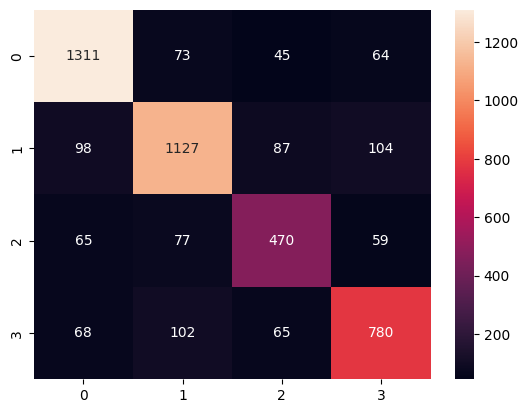

In [28]:

# create svm classifier for each label
classifiers = []
for i in range(class_number):
    # clf = SVC(kernel='rbf', C=1.0, tol=1e-2,verbose=True, class_weight='balanced', max_iter=2000)
    clf = LinearSVC(C=0.1,tol=1e-2, loss='squared_hinge', class_weight='balanced', max_iter=2000, dual=True)
    clf.fit(X_train_counts, y_train == i)
    classifiers.append(clf)
# evaluate each classifier on validation set
all_scores=np.zeros((X_val_counts.shape[0], class_number))
for i in range(class_number):
        all_scores[:, i] = classifiers[i].decision_function(X_val_counts)

final_predictions = np.argmax(all_scores, axis=1)
print(classification_report(y_val, final_predictions))
sns.heatmap(confusion_matrix(y_val, final_predictions),annot=True, fmt='d')

# podejście OvO

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1492
           1       0.82      0.81      0.82      1416
           2       0.68      0.71      0.70       672
           3       0.80      0.76      0.78      1015

    accuracy                           0.80      4595
   macro avg       0.79      0.79      0.79      4595
weighted avg       0.80      0.80      0.80      4595



<Axes: >

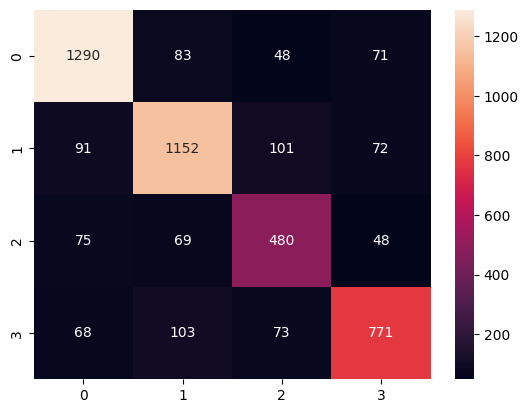

In [29]:
classifiers = {}
for i in range(class_number):
    for j in range(i+1, class_number):
        mask = (y_train.values == i) | (y_train.values == j)
        X_train_pair = X_train_counts[mask]
        y_train_pair = (y_train[mask]==i)
        
        clf = LinearSVC(C=0.1,tol=1e-2, loss='squared_hinge',class_weight='balanced', max_iter=2000)
        clf.fit(X_train_pair, y_train_pair)
        classifiers[(i, j)] = clf

confidence_scores=np.zeros((X_test_counts.shape[0], class_number))
for (i, j), clf in classifiers.items():
    score = clf.decision_function(X_test_counts)
    confidence_scores[:, i] += score
    confidence_scores[:, j] -= score

finals = np.argmax(confidence_scores, axis=1)
print(classification_report(y_test, finals))
sns.heatmap(confusion_matrix(y_test, finals), annot=True, fmt='d')
    